# Exploring the Bitcoin Cryptocurrency Market

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bilalsuppal/exploring-the-bitcoin-cryptocurrency-markets", output_dir="datasets")

print("Path to dataset files:", path)

d:\Projects\Assignment\Courses\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 67.6k/67.6k [00:00<00:00, 244kB/s]

Extracting files...
Path to dataset files: datasets


In [84]:
import seaborn as sns

In [48]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

# load the dataset 
df = pd.read_csv('datasets\coinmarketcap_06122017.csv')

print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (1326, 16)


,Unnamed: 0,24h_volume_usd,available_supply,id,last_updated,market_cap_usd,max_supply,name,percent_change_1h,percent_change_24h,percent_change_7d,price_btc,price_usd,rank,symbol,total_supply
0,0,9.007640e+09,1.672352e+07,bitcoin,1512549554,2.130493e+11,2.100000e+07,Bitcoin,0.12,7.33,17.45,1.000000,12739.500000,1,BTC,1.672352e+07
1,1,1.551330e+09,9.616537e+07,ethereum,1512549553,4.352945e+10,NaN,Ethereum,-0.18,-3.93,-7.33,0.036177,452.652000,2,ETH,9.616537e+07
2,2,1.111350e+09,1.684044e+07,bitcoin-cash,1512549578,2.529585e+10,2.100000e+07,Bitcoin Cash,1.65,-5.51,-4.75,0.120050,1502.090000,3,BCH,1.684044e+07
3,3,2.936090e+09,2.779530e+09,iota,1512549571,1.475225e+10,2.779530e+09,IOTA,-2.38,83.35,255.82,0.000424,5.307460,4,MIOTA,2.779530e+09
4,4,2.315050e+08,3.873915e+10,ripple,1512549541,9.365343e+09,1.000000e+11,Ripple,0.56,-3.70,-14.79,0.000019,0.241754,5,XRP,9.999309e+10


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1326 entries, 0 to 1325
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          1326 non-null   int64  
 1   24h_volume_usd      1270 non-null   float64
 2   available_supply    1031 non-null   float64
 3   id                  1326 non-null   str    
 4   last_updated        1326 non-null   int64  
 5   market_cap_usd      1031 non-null   float64
 6   max_supply          215 non-null    float64
 7   name                1326 non-null   str    
 8   percent_change_1h   1273 non-null   float64
 9   percent_change_24h  1270 non-null   float64
 10  percent_change_7d   1283 non-null   float64
 11  price_btc           1326 non-null   float64
 12  price_usd           1326 non-null   float64
 13  rank                1326 non-null   int64  
 14  symbol              1326 non-null   str    
 15  total_supply        1211 non-null   float64
dtypes: float64(10), i

In [33]:
df.columns

Index(['Unnamed: 0', '24h_volume_usd', 'available_supply', 'id',
       'last_updated', 'market_cap_usd', 'max_supply', 'name',
       'percent_change_1h', 'percent_change_24h', 'percent_change_7d',
       'price_btc', 'price_usd', 'rank', 'symbol', 'total_supply'],
      dtype='str')

# Data cleaning

In [34]:
len(df['rank'].unique())

1326

In [49]:
# 1. drop the columns that are not needed for analysis
columns_to_drop = ['Unnamed: 0' , 'id' , 'name' , 'rank' , 'price_btc']

df = df.drop(columns=columns_to_drop)

df.head()

,24h_volume_usd,available_supply,last_updated,market_cap_usd,max_supply,percent_change_1h,percent_change_24h,percent_change_7d,price_usd,symbol,total_supply
0,9.007640e+09,1.672352e+07,1512549554,2.130493e+11,2.100000e+07,0.12,7.33,17.45,12739.500000,BTC,1.672352e+07
1,1.551330e+09,9.616537e+07,1512549553,4.352945e+10,NaN,-0.18,-3.93,-7.33,452.652000,ETH,9.616537e+07
2,1.111350e+09,1.684044e+07,1512549578,2.529585e+10,2.100000e+07,1.65,-5.51,-4.75,1502.090000,BCH,1.684044e+07
3,2.936090e+09,2.779530e+09,1512549571,1.475225e+10,2.779530e+09,-2.38,83.35,255.82,5.307460,MIOTA,2.779530e+09
4,2.315050e+08,3.873915e+10,1512549541,9.365343e+09,1.000000e+11,0.56,-3.70,-14.79,0.241754,XRP,9.999309e+10


In [50]:
# 2. check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
24h_volume_usd          56
available_supply       295
last_updated             0
market_cap_usd         295
max_supply            1111
percent_change_1h       53
percent_change_24h      56
percent_change_7d       43
price_usd                0
symbol                   0
total_supply           115
dtype: int64


In [51]:
missing_values > df.shape[0] * 0.5

24h_volume_usd        False
available_supply      False
last_updated          False
market_cap_usd        False
max_supply             True
percent_change_1h     False
percent_change_24h    False
percent_change_7d     False
price_usd             False
symbol                False
total_supply          False
dtype: bool

In [52]:
# drop columns over 50% missing values
columns_to_drop = missing_values[missing_values > df.shape[0]* 0.5].index

df = df.drop(columns=columns_to_drop)

# remove rows without market cap and available supply data
df = df.dropna(subset=['market_cap_usd', 'available_supply'])

# Percentage columns (very important) 
percent_cols = ['percent_change_1h', 'percent_change_24h', 'percent_change_7d']
df[percent_cols] = df[percent_cols].fillna(0) # because no change in price is a reasonable assumption

# Fill numeric columns with median
num_cols = ['24h_volume_usd', 'total_supply']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:")
print(df.isnull().sum())
df.head()

Missing values after imputation:
24h_volume_usd        0
available_supply      0
last_updated          0
market_cap_usd        0
percent_change_1h     0
percent_change_24h    0
percent_change_7d     0
price_usd             0
symbol                0
total_supply          0
dtype: int64


,24h_volume_usd,available_supply,last_updated,market_cap_usd,percent_change_1h,percent_change_24h,percent_change_7d,price_usd,symbol,total_supply
0,9.007640e+09,1.672352e+07,1512549554,2.130493e+11,0.12,7.33,17.45,12739.500000,BTC,1.672352e+07
1,1.551330e+09,9.616537e+07,1512549553,4.352945e+10,-0.18,-3.93,-7.33,452.652000,ETH,9.616537e+07
2,1.111350e+09,1.684044e+07,1512549578,2.529585e+10,1.65,-5.51,-4.75,1502.090000,BCH,1.684044e+07
3,2.936090e+09,2.779530e+09,1512549571,1.475225e+10,-2.38,83.35,255.82,5.307460,MIOTA,2.779530e+09
4,2.315050e+08,3.873915e+10,1512549541,9.365343e+09,0.56,-3.70,-14.79,0.241754,XRP,9.999309e+10


In [53]:
df.shape

(1031, 10)

In [56]:
len(df['symbol'].unique())

1020

In [59]:
df.groupby('symbol')['market_cap_usd'].agg(['count' , 'mean']).sort_values(by = 'mean' , ascending=False)

,count,mean
symbol,,
BTC,1,2.130493e+11
ETH,1,4.352945e+10
BCH,1,2.529585e+10
MIOTA,1,1.475225e+10
XRP,1,9.365343e+09
...,...,...
FDC,1,2.510000e+02
ENV,1,1.360000e+02
CALC,1,1.000000e+02


# 1. Data Aggregation

In [97]:
df.groupby('symbol')['price_usd'].mean()

symbol
$$$        0.001772
1337       0.000058
1ST        0.453827
2GIVE      0.010011
300      175.310000
            ...    
ZRC        1.753760
ZRX        0.225418
ZSC        0.032692
ZUR        0.004379
ZYD        0.004630
Name: price_usd, Length: 1020, dtype: float64

In [98]:
df.groupby(['symbol', 'last_updated'])['market_cap_usd'].mean()

symbol  last_updated
$$$     1512549561          81291.0
1337    1512549551        1369097.0
1ST     1512549558       38828699.0
2GIVE   1512549556        5189514.0
300     1512549572          52593.0
                           ...     
ZRC     1512549568        6384584.0
ZRX     1512549574      112709000.0
ZSC     1512549579       37699805.0
ZUR     1512549555         381215.0
ZYD     1512549558          28906.0
Name: market_cap_usd, Length: 1031, dtype: float64

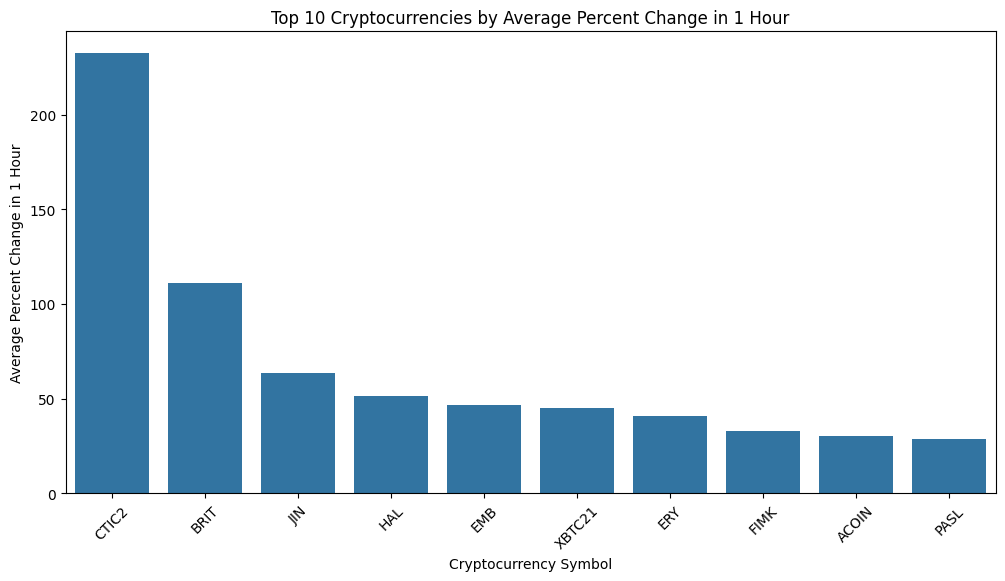

In [92]:
pv = df.groupby('symbol')[['percent_change_1h']].mean().sort_values(by = 'percent_change_1h' , ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x = pv.index , y = pv['percent_change_1h'].values)
plt.xticks(rotation=45)
plt.title('Top 10 Cryptocurrencies by Average Percent Change in 1 Hour')
plt.xlabel('Cryptocurrency Symbol')
plt.ylabel('Average Percent Change in 1 Hour')
plt.show()

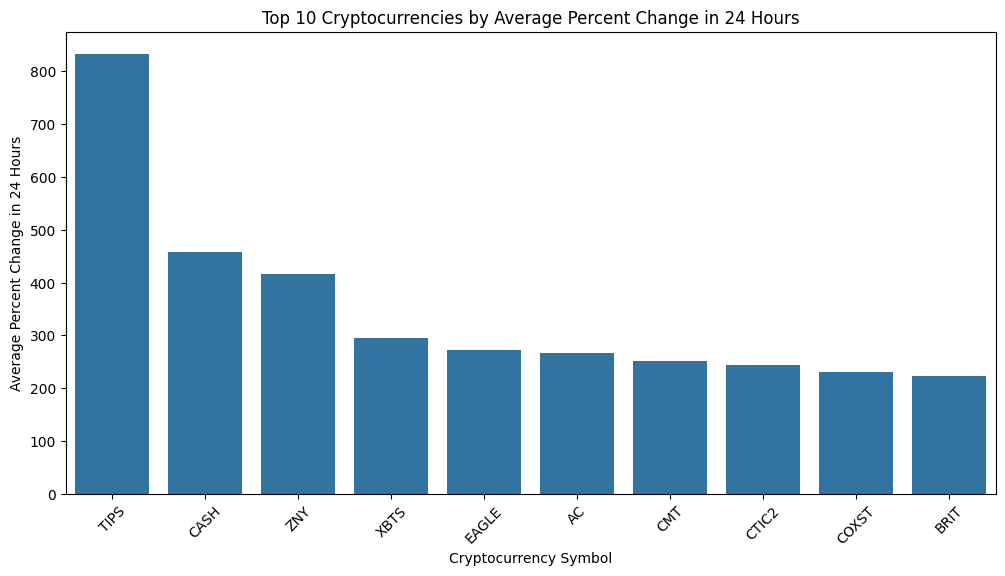

In [93]:
pv = df.groupby('symbol')[['percent_change_24h']].mean().sort_values(by = 'percent_change_24h' , ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x = pv.index , y = pv['percent_change_24h'].values)
plt.xticks(rotation=45)
plt.title('Top 10 Cryptocurrencies by Average Percent Change in 24 Hours')
plt.xlabel('Cryptocurrency Symbol')
plt.ylabel('Average Percent Change in 24 Hours')
plt.show()

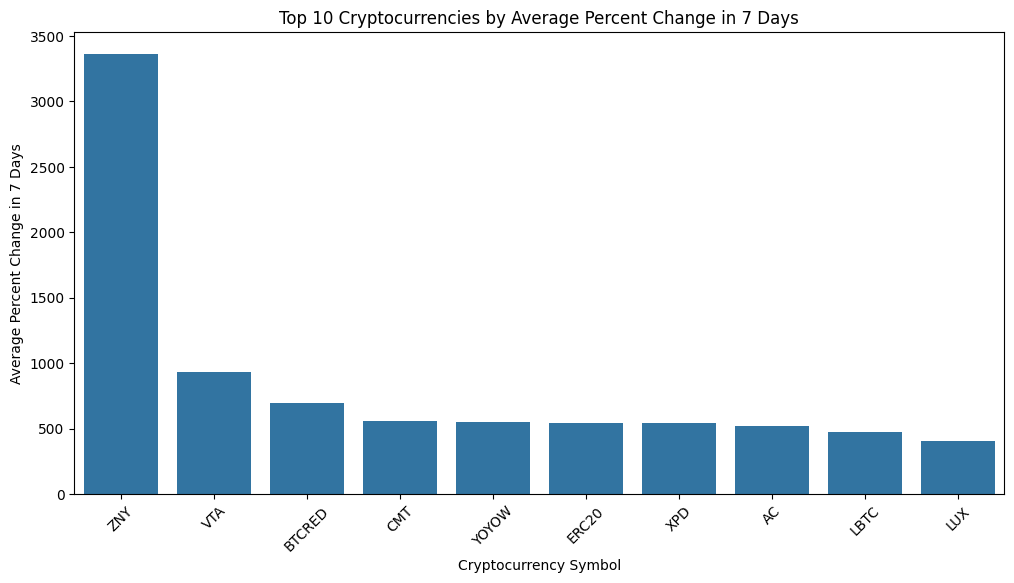

In [94]:
pv = df.groupby('symbol')[['percent_change_7d']].mean().sort_values(by = 'percent_change_7d' , ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x = pv.index , y = pv['percent_change_7d'].values)
plt.xticks(rotation=45)
plt.title('Top 10 Cryptocurrencies by Average Percent Change in 7 Days')
plt.xlabel('Cryptocurrency Symbol')
plt.ylabel('Average Percent Change in 7 Days')
plt.show()

In [ ]:
df.pivot_table(index='symbol', values=['percent_change_1h', 'percent_change_24h', 'percent_change_7d'], aggfunc='mean').sort_values(by='percent_change_7d', ascending=False)
# pivot_table(index , values : values we want to aggregate , aggfunc , columns)

,percent_change_1h,percent_change_24h,percent_change_7d
symbol,,,
ZNY,12.23,416.04,3360.71
VTA,-0.15,0.00,928.97
BTCRED,2.77,-29.87,693.37
CMT,7.58,252.07,560.46
YOYOW,10.07,119.59,547.12
...,...,...,...
E4ROW,0.00,-3.05,-75.03
JET,-20.67,-36.03,-80.66
ECA,0.50,-40.59,-81.29


# 2. Data Transformation

In [99]:
df.head()

,24h_volume_usd,available_supply,last_updated,market_cap_usd,percent_change_1h,percent_change_24h,percent_change_7d,price_usd,symbol,total_supply
0,9.007640e+09,1.672352e+07,1512549554,2.130493e+11,0.12,7.33,17.45,12739.500000,BTC,1.672352e+07
1,1.551330e+09,9.616537e+07,1512549553,4.352945e+10,-0.18,-3.93,-7.33,452.652000,ETH,9.616537e+07
2,1.111350e+09,1.684044e+07,1512549578,2.529585e+10,1.65,-5.51,-4.75,1502.090000,BCH,1.684044e+07
3,2.936090e+09,2.779530e+09,1512549571,1.475225e+10,-2.38,83.35,255.82,5.307460,MIOTA,2.779530e+09
4,2.315050e+08,3.873915e+10,1512549541,9.365343e+09,0.56,-3.70,-14.79,0.241754,XRP,9.999309e+10


In [100]:
# Calculate supply ratio and market share percentage
df['supply_ratio'] = df['market_cap_usd'] / df['price_usd']

total_market_cap = df['market_cap_usd'].sum()
df['market_share_pct'] = (df['market_cap_usd'] / total_market_cap) * 100

# 3. Data Filtering

In [102]:
df['price_usd'].mean()

np.float64(506.470356501204)

In [ ]:
# penny coins 

cheap_coins = df[df['price_usd'] < 0.5]

cheap_coins.shape[0]

759

In [ ]:
# Multiple Conditions

high_performers = df[(df['24h_volume_usd'] > 20199685) & (df['percent_change_24h'] > 0)]

high_performers.shape[0] , high_performers.head()

(18,
     24h_volume_usd  available_supply  last_updated  market_cap_usd  \
 0     9.007640e+09      1.672352e+07    1512549554    2.130493e+11   
 3     2.936090e+09      2.779530e+09    1512549571    1.475225e+10   
 6     4.093420e+08      5.415391e+07    1512549542    5.634498e+09   
 8     5.498600e+08      1.544296e+07    1512549544    4.331688e+09   
 12    2.490480e+08      5.199591e+08    1512549570    2.567610e+09   
 
     percent_change_1h  percent_change_24h  percent_change_7d    price_usd  \
 0                0.12                7.33              17.45  12739.50000   
 3               -2.38               83.35             255.82      5.30746   
 6               -0.17                0.80               3.68    104.04600   
 8               -2.00               25.65              41.23    280.49600   
 12               2.26               29.56              69.66      4.93810   
 
    symbol  total_supply  supply_ratio  market_share_pct  
 0     BTC  1.672352e+07  1.672353e+07

In [ ]:
# Complex Filtering (The "Not" operator)

# Get everything EXCEPT the symbol 'BTC'
alt_coins_only = df[~(df['symbol'] == 'BTC')]

alt_coins_only.shape

(1030, 12)

# 4. Conditional Operations

<Axes: ylabel='Frequency'>

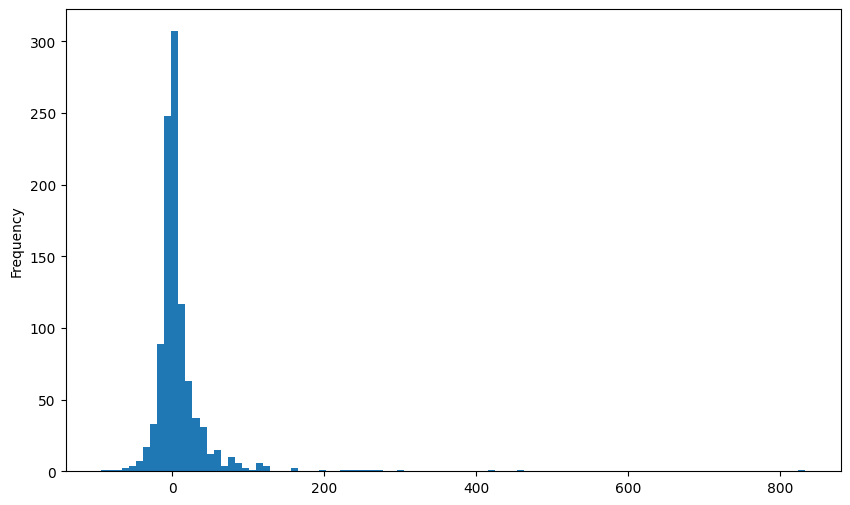

In [128]:
df['percent_change_24h'].plot(kind='hist', bins=100, figsize=(10, 6))

In [127]:
df.head()

,24h_volume_usd,available_supply,last_updated,market_cap_usd,percent_change_1h,percent_change_24h,percent_change_7d,price_usd,symbol,total_supply,supply_ratio,market_share_pct
0,9.007640e+09,1.672352e+07,1512549554,2.130493e+11,0.12,7.33,17.45,12739.500000,BTC,1.672352e+07,1.672353e+07,56.918669
1,1.551330e+09,9.616537e+07,1512549553,4.352945e+10,-0.18,-3.93,-7.33,452.652000,ETH,9.616537e+07,9.616537e+07,11.629410
2,1.111350e+09,1.684044e+07,1512549578,2.529585e+10,1.65,-5.51,-4.75,1502.090000,BCH,1.684044e+07,1.684044e+07,6.758088
3,2.936090e+09,2.779530e+09,1512549571,1.475225e+10,-2.38,83.35,255.82,5.307460,MIOTA,2.779530e+09,2.779530e+09,3.941238
4,2.315050e+08,3.873915e+10,1512549541,9.365343e+09,0.56,-3.70,-14.79,0.241754,XRP,9.999309e+10,3.873915e+10,2.502063


In [129]:
df['percent_change_24h'].mean()

np.float64(9.137478176527642)

In [133]:
df['status'] = np.where(df['percent_change_24h'] > 9, 'High Growth', 'Stable/Down')
df['percent_change_24h_binned'] = pd.qcut(df['percent_change_24h'], q=4, labels=['low', 'Medium', 'High', 'Very High'])

In [134]:
df.head()

,24h_volume_usd,available_supply,last_updated,market_cap_usd,percent_change_1h,percent_change_24h,percent_change_7d,price_usd,symbol,total_supply,supply_ratio,market_share_pct,status,percent_change_24h_binned
0,9.007640e+09,1.672352e+07,1512549554,2.130493e+11,0.12,7.33,17.45,12739.500000,BTC,1.672352e+07,1.672353e+07,56.918669,Stable/Down,High
1,1.551330e+09,9.616537e+07,1512549553,4.352945e+10,-0.18,-3.93,-7.33,452.652000,ETH,9.616537e+07,9.616537e+07,11.629410,Stable/Down,Medium
2,1.111350e+09,1.684044e+07,1512549578,2.529585e+10,1.65,-5.51,-4.75,1502.090000,BCH,1.684044e+07,1.684044e+07,6.758088,Stable/Down,Medium
3,2.936090e+09,2.779530e+09,1512549571,1.475225e+10,-2.38,83.35,255.82,5.307460,MIOTA,2.779530e+09,2.779530e+09,3.941238,High Growth,Very High
4,2.315050e+08,3.873915e+10,1512549541,9.365343e+09,0.56,-3.70,-14.79,0.241754,XRP,9.999309e+10,3.873915e+10,2.502063,Stable/Down,Medium


In [135]:
df.shape

(1031, 14)